In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import Model, Input ## functional API

from keras.layers import (### dense neural network
                                    Dense, Flatten,

                                    ### convolutionnal neural network
                                    Reshape, Convolution2D, MaxPooling2D, AveragePooling2D,

                                    ### data augmentation
                                    Rescaling,RandomRotation, RandomFlip,

                                    ### regularisation
                                    Dropout,
                                    
                                    ### parallel sub-models, use functionnal API
                                    Concatenate,

                                    )
                

from keras.datasets import mnist,fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
        if metric == 'accuracy':
            plt.ylim(0,1.1)
    plt.show()




def plot_cm_display(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    
    #plt.figure(figsize=(20, 8))
    #plt.title('Confusion Matrix\n')
    CM = ConfusionMatrixDisplay(cm)
    CM.plot()
    #sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    #plt.xlabel('y_pred')
    #plt.ylabel('y_true')
    plt.show()

# Data

k=i=bv

In [3]:
def add_noise(X,noise_factor=0.05):

    SHAPE = X.shape

    ### garder les valeurs entre min et max originale
    X_noise = np.clip(a_max=np.max(X,axis=None),
                      a_min=np.min(X,axis=None),
                      a=X + noise_factor * np.random.normal(0,np.max(X,axis=None),SHAPE), ## loi normale centrée reduite
                     ) 
    
    return X_noise

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train/np.max(X_train,axis=None)
X_test = X_test/np.max(X_test,axis=None)

noise_factor=0.3
X_train_noise,X_test_noise = add_noise(X_train,noise_factor),add_noise(X_test,noise_factor)

## start classifier

In [5]:
def mymodel(n_class= 10, input_shape = (28,28), activation='relu'):


    ### start model structure
    inputs = Input(input_shape)

    x = Reshape((28,28,1))(inputs)
    
    x = Convolution2D(filters=16, kernel_size=7, activation=activation, padding='same')(x)
    x = Convolution2D(filters=16, kernel_size=5, activation=activation, padding='same')(x)
    x = MaxPooling2D(2)(x)

    x = Convolution2D(filters=16, kernel_size=5, activation=activation, padding='same')(x)
    x = MaxPooling2D(2)(x)

    x1 = Convolution2D(filters=16, kernel_size=2, activation=activation, padding='same')(x)
    x1 = MaxPooling2D(2)(x1)

    x2 = Convolution2D(filters=16, kernel_size=2, activation=activation, padding='same')(x1)
    x2 = MaxPooling2D(2)(x2)

    y0 = Flatten()(x)
    y1 = Flatten()(x1)
    y2 = Flatten()(x2)

    y = Concatenate()([y0,y1,y2])

    y = Dense(units=128, activation=activation)(y)
    y = Dropout(0.5)(y)
    output = Dense(n_class, activation='softmax')(y)
    ### end model structure
    
    model = Model(inputs=inputs,outputs=output)
    
    ### compiler quand modele est complet/fini
    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

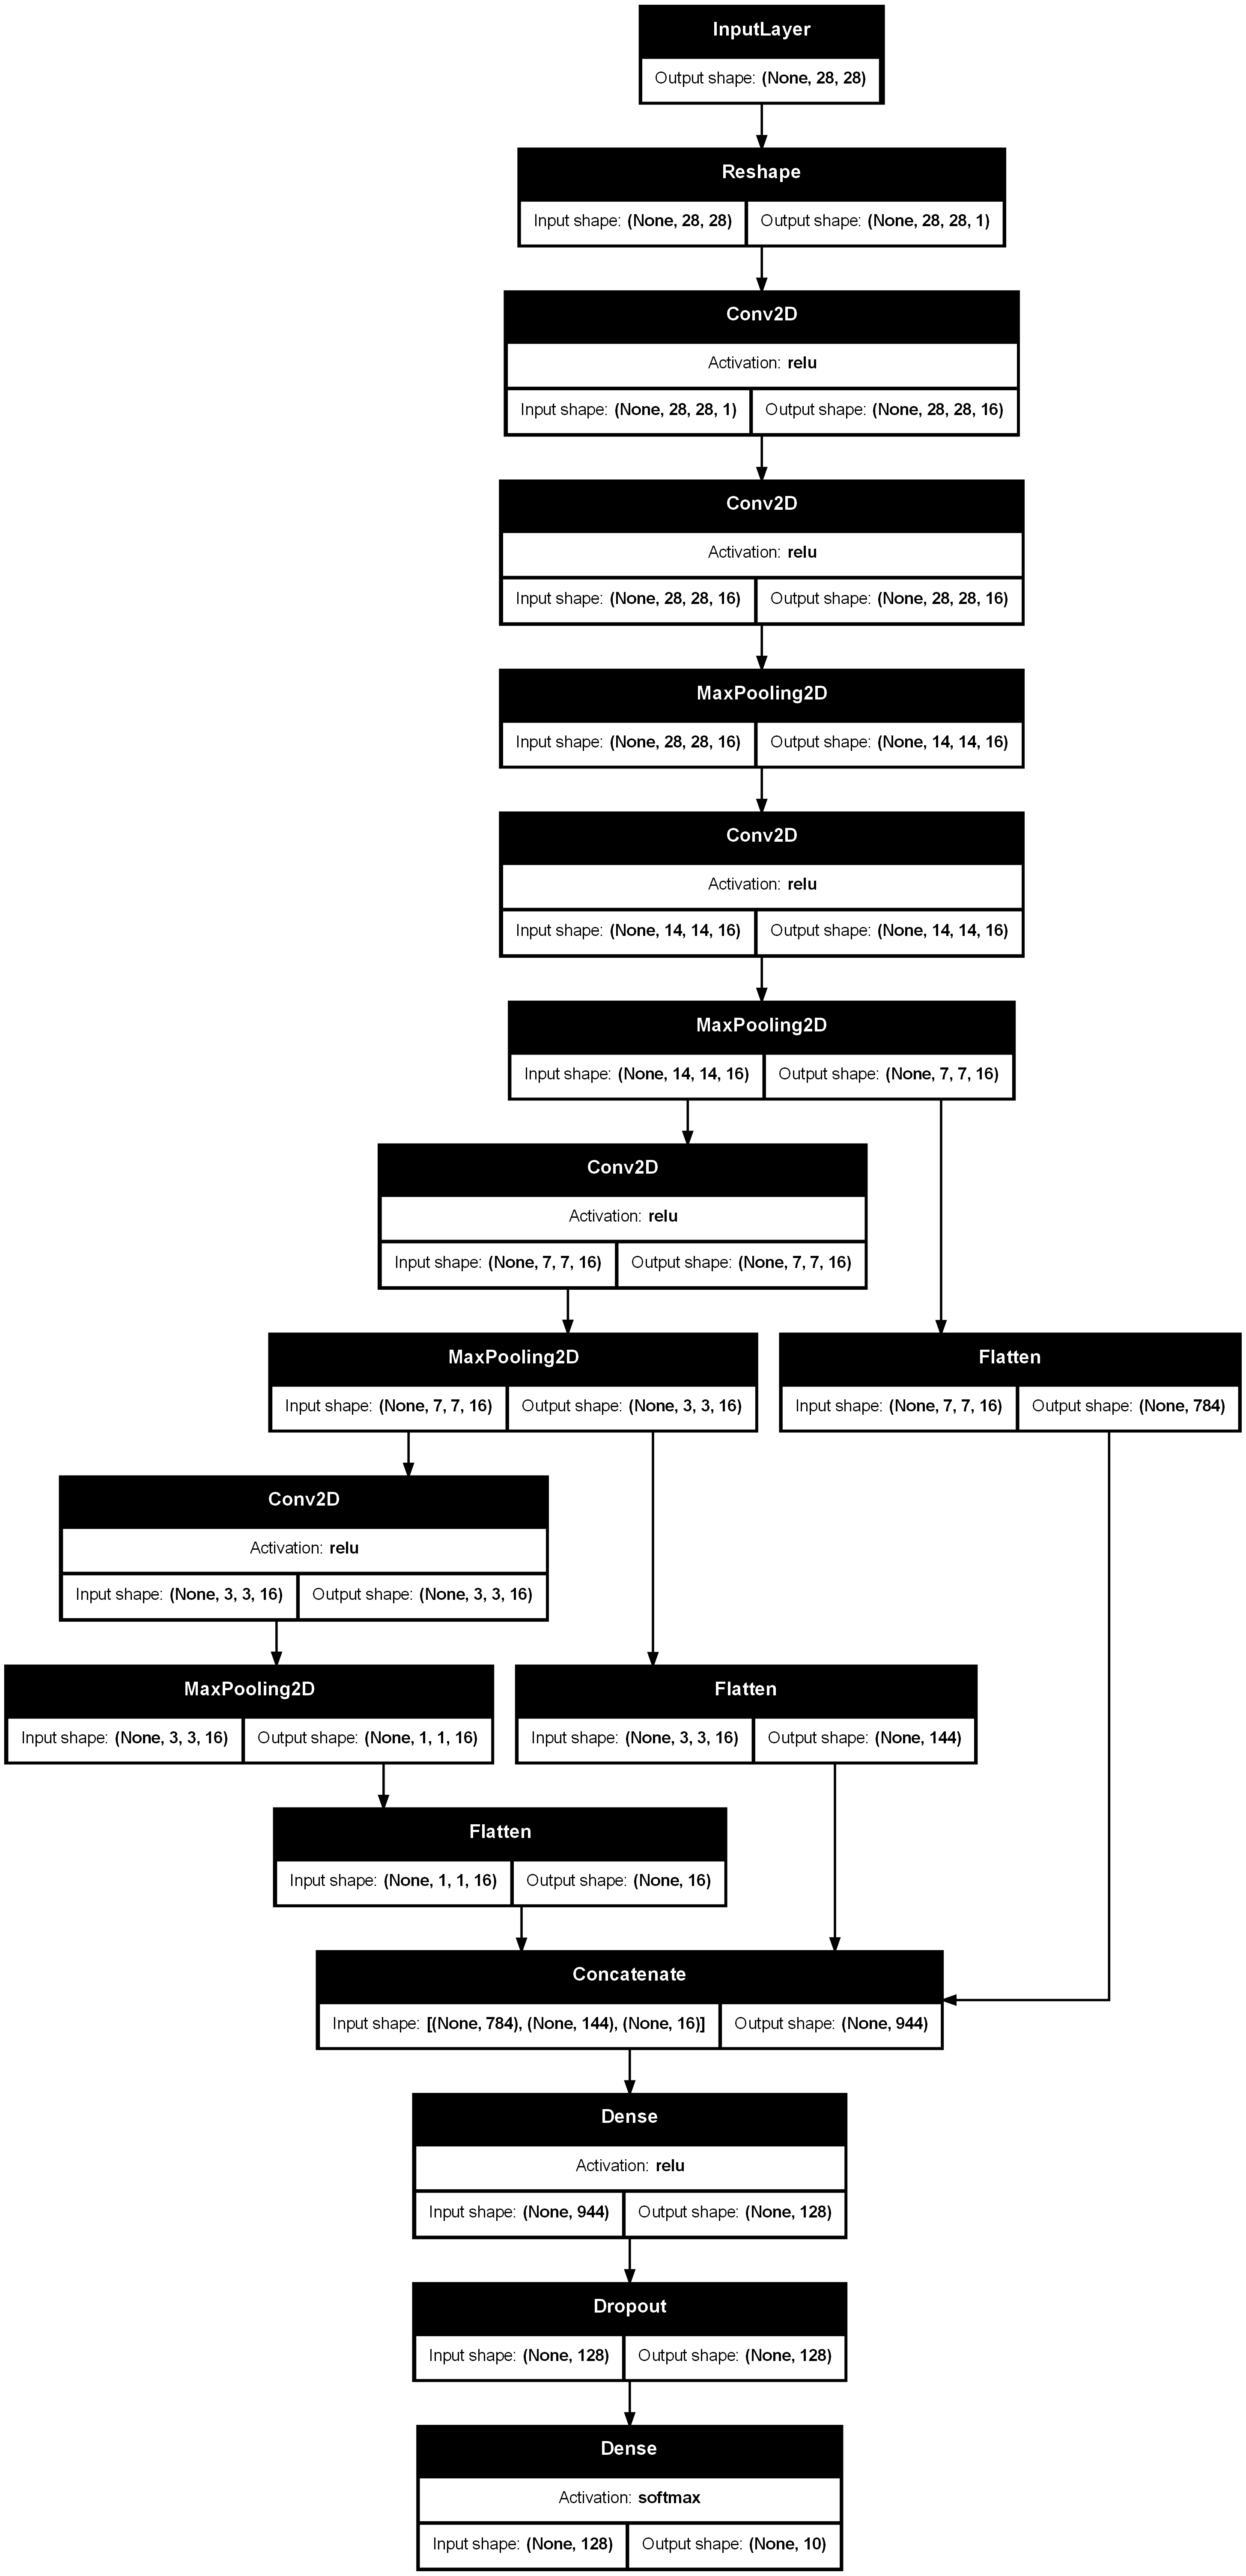

In [6]:
model = mymodel()
keras.utils.plot_model(
    model = model,
    show_layer_activations=True,
    show_shapes=True,
    expand_nested=True
)

In [9]:
model.fit(X_train_noise, y_train, validation_split=.2, epochs=2, batch_size=256)

Epoch 1/2
188/188 ━━━━━━━━━━━━━━━━━━━━ 27s 142ms/step - accuracy: 0.8704 - loss: 0.4144 - val_accuracy: 0.9629 - val_loss: 0.1222
Epoch 2/2
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 135ms/step - accuracy: 0.9459 - loss: 0.1804 - val_accuracy: 0.9724 - val_loss: 0.0881


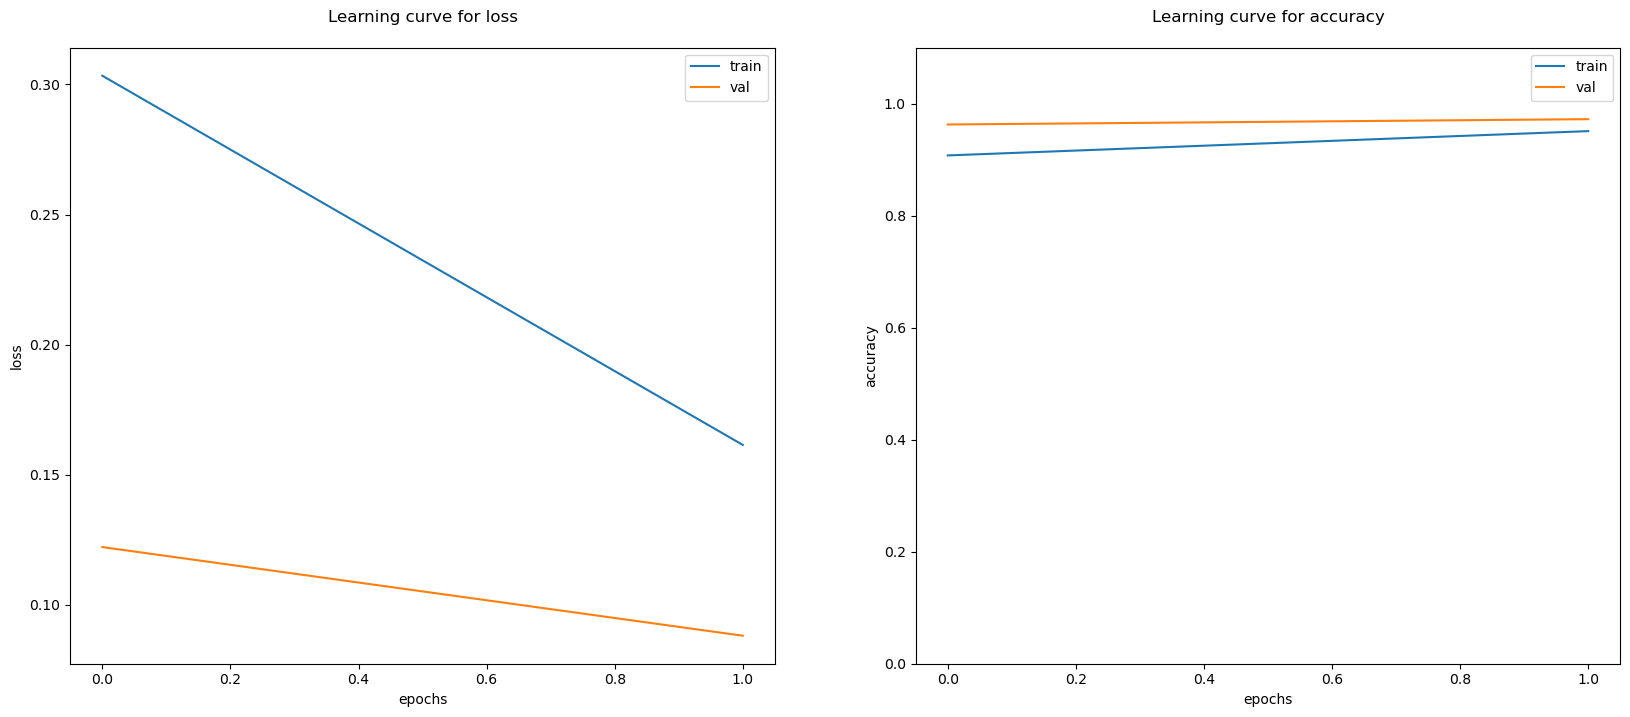

In [10]:
plot_lc(history=model.history.history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


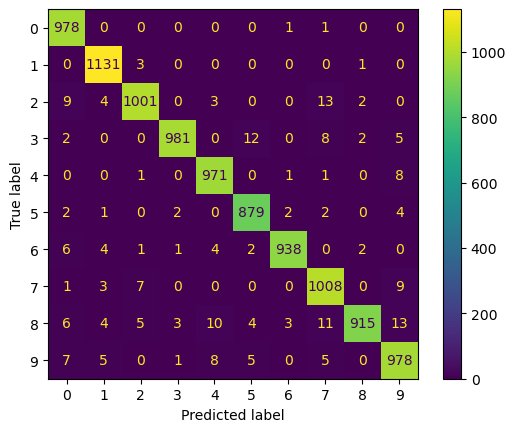

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.99      0.97      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.97      0.99      0.98       892
           6       0.99      0.98      0.99       958
           7       0.96      0.98      0.97      1028
           8       0.99      0.94      0.97       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [11]:
y_pred = np.argmax(model.predict(X_test), axis=1)

plot_cm_display(y_test, y_pred)
print(classification_report(y_test, y_pred))

# recup d'un modele pre-entrainé


In [12]:
layers = model.layers
print(layers)

[<InputLayer name=input_layer, built=True>, <Reshape name=reshape, built=True>, <Conv2D name=conv2d, built=True>, <Conv2D name=conv2d_1, built=True>, <MaxPooling2D name=max_pooling2d, built=True>, <Conv2D name=conv2d_2, built=True>, <MaxPooling2D name=max_pooling2d_1, built=True>, <Conv2D name=conv2d_3, built=True>, <MaxPooling2D name=max_pooling2d_2, built=True>, <Conv2D name=conv2d_4, built=True>, <MaxPooling2D name=max_pooling2d_3, built=True>, <Flatten name=flatten, built=True>, <Flatten name=flatten_1, built=True>, <Flatten name=flatten_2, built=True>, <Concatenate name=concatenate, built=True>, <Dense name=dense, built=True>, <Dropout name=dropout, built=True>, <Dense name=dense_1, built=True>]


In [13]:
layer_name = model.layers[-2].name ## recup le nom de l'avant dernière couche


sub_model = Model(inputs=model.input,
                outputs=model.get_layer(layer_name).output) ## sub_model = model sauf la dernière

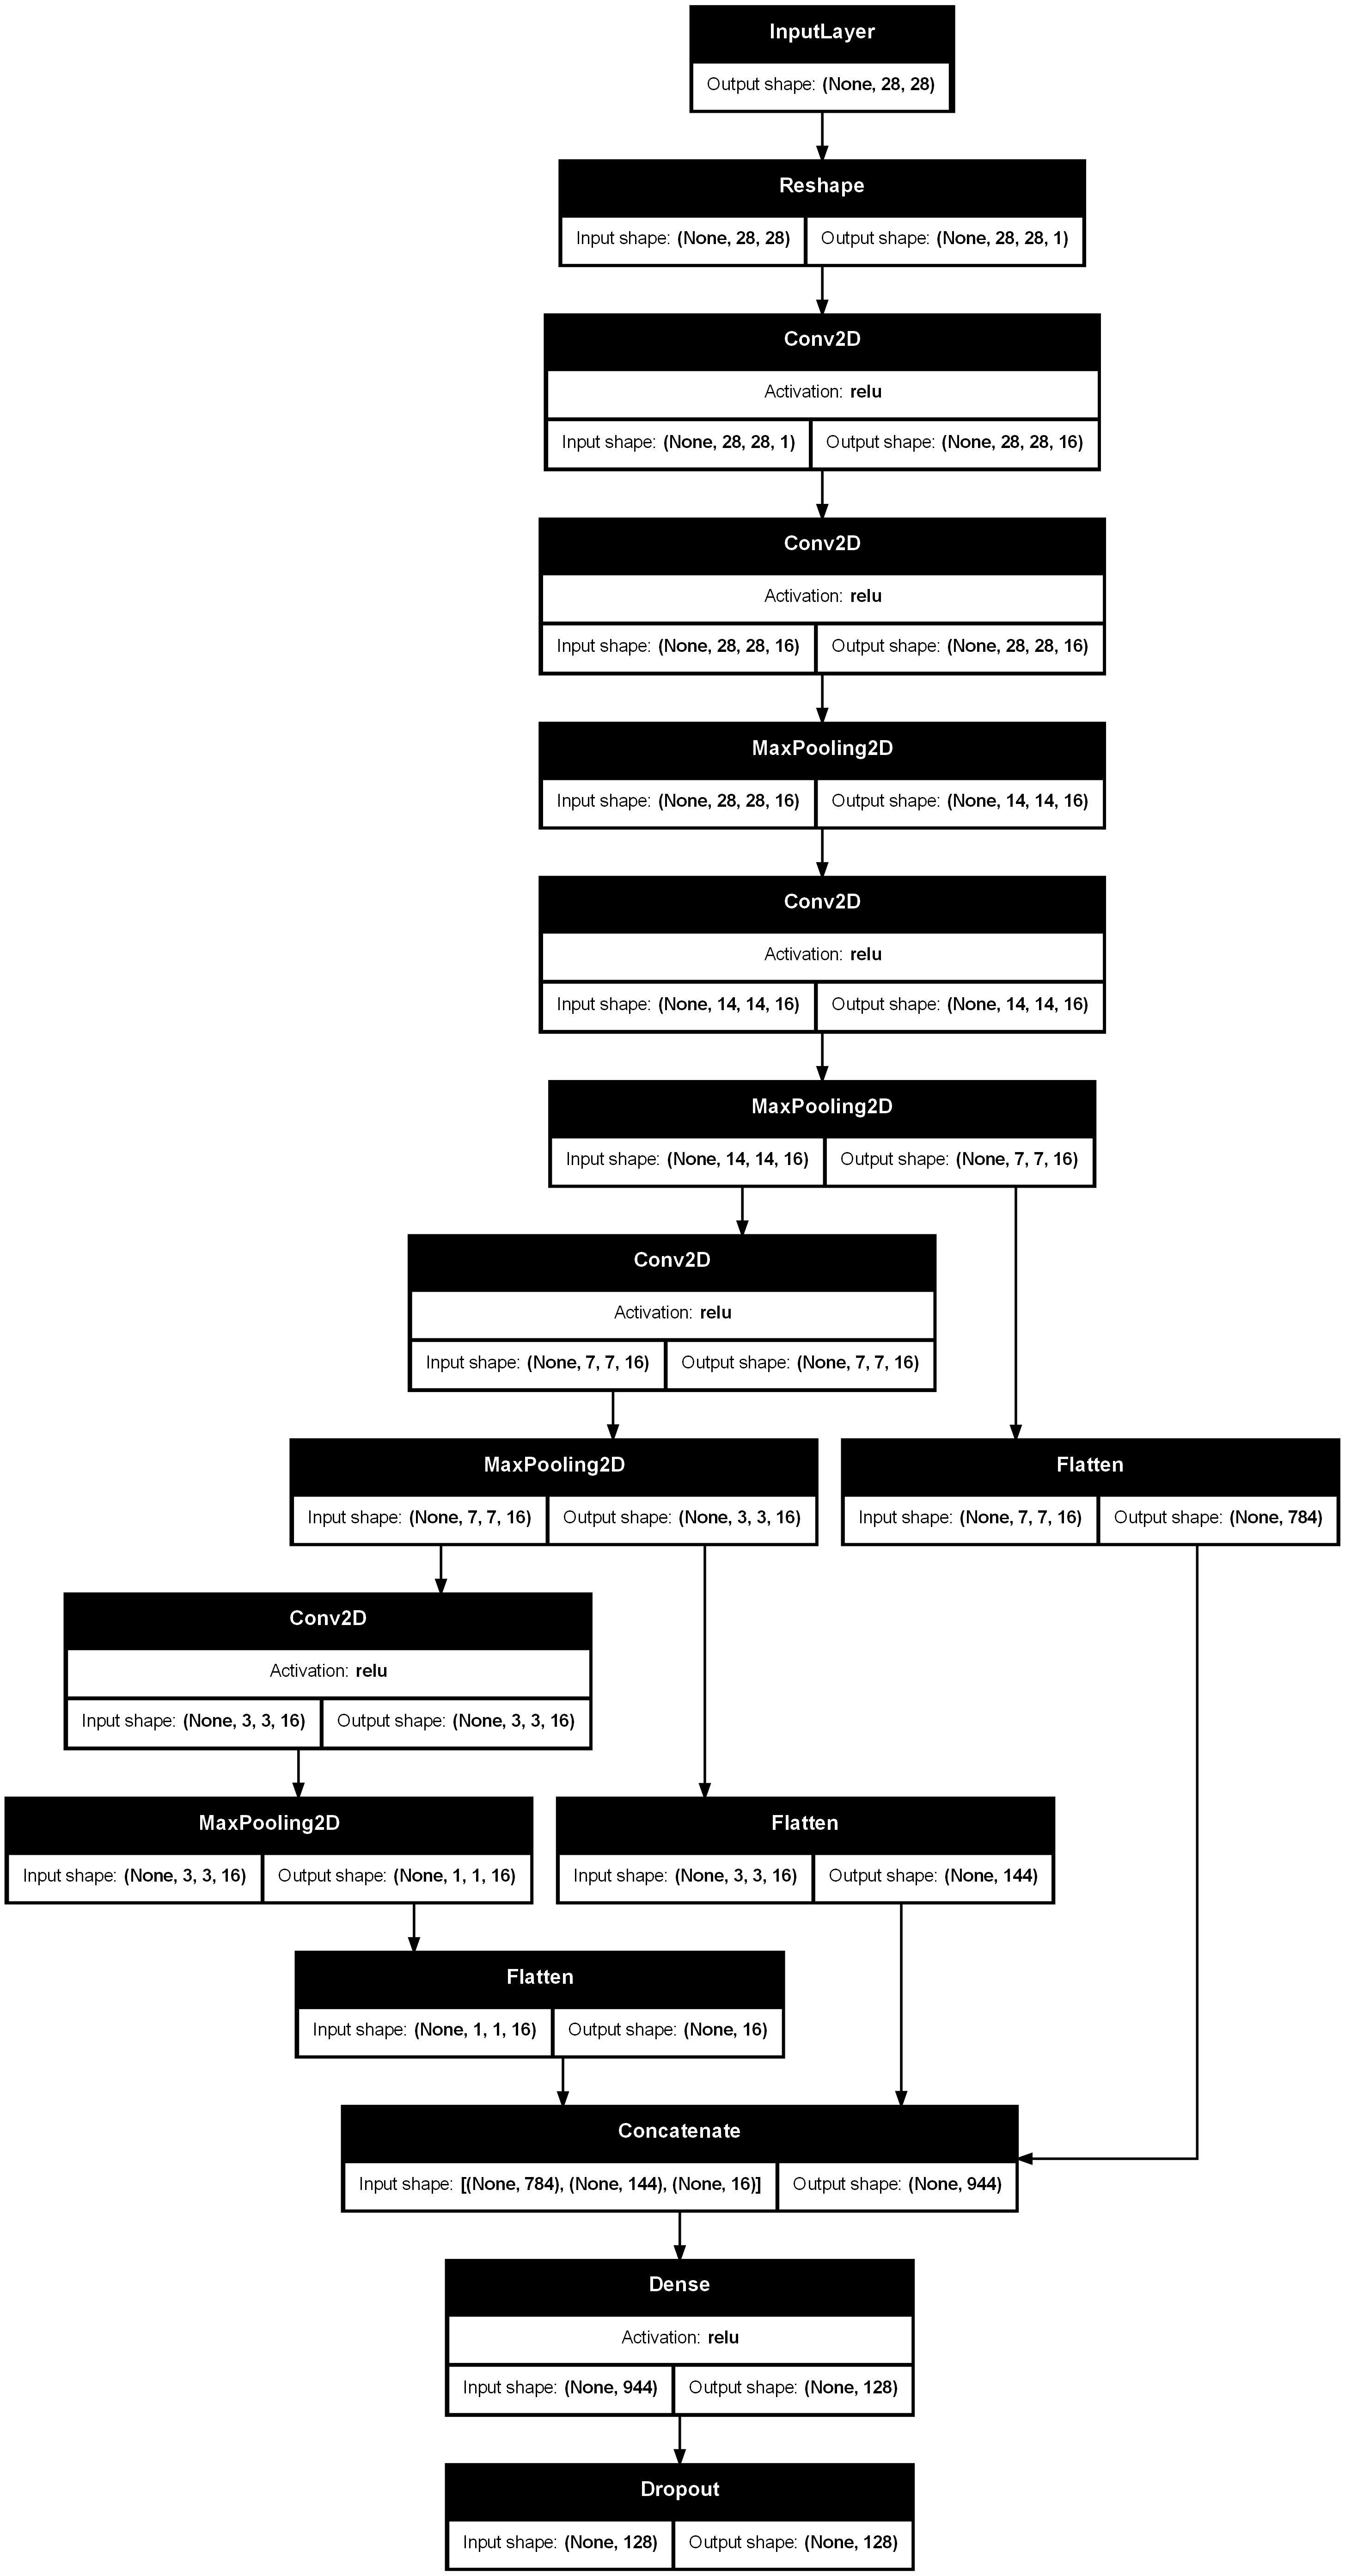

In [14]:
tf.keras.utils.plot_model(
    model = sub_model,
    show_layer_activations=True,
    show_shapes=True,
    expand_nested=True
)

In [15]:
def mymodel_2(sub_model:Model,n_class= 10, input_shape = (28,28), activation='relu'):
    
    sub_model.trainable=False
    
    inputs= Input(input_shape)
    
    x = sub_model(inputs) ## utilisation du modèle existant

    x = Dense(units=64,activation=activation) (x) ## ajout d'une couche 64 neurones
    
    outputs = Dense(units=n_class,activation='softmax')(x) ## dernière

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

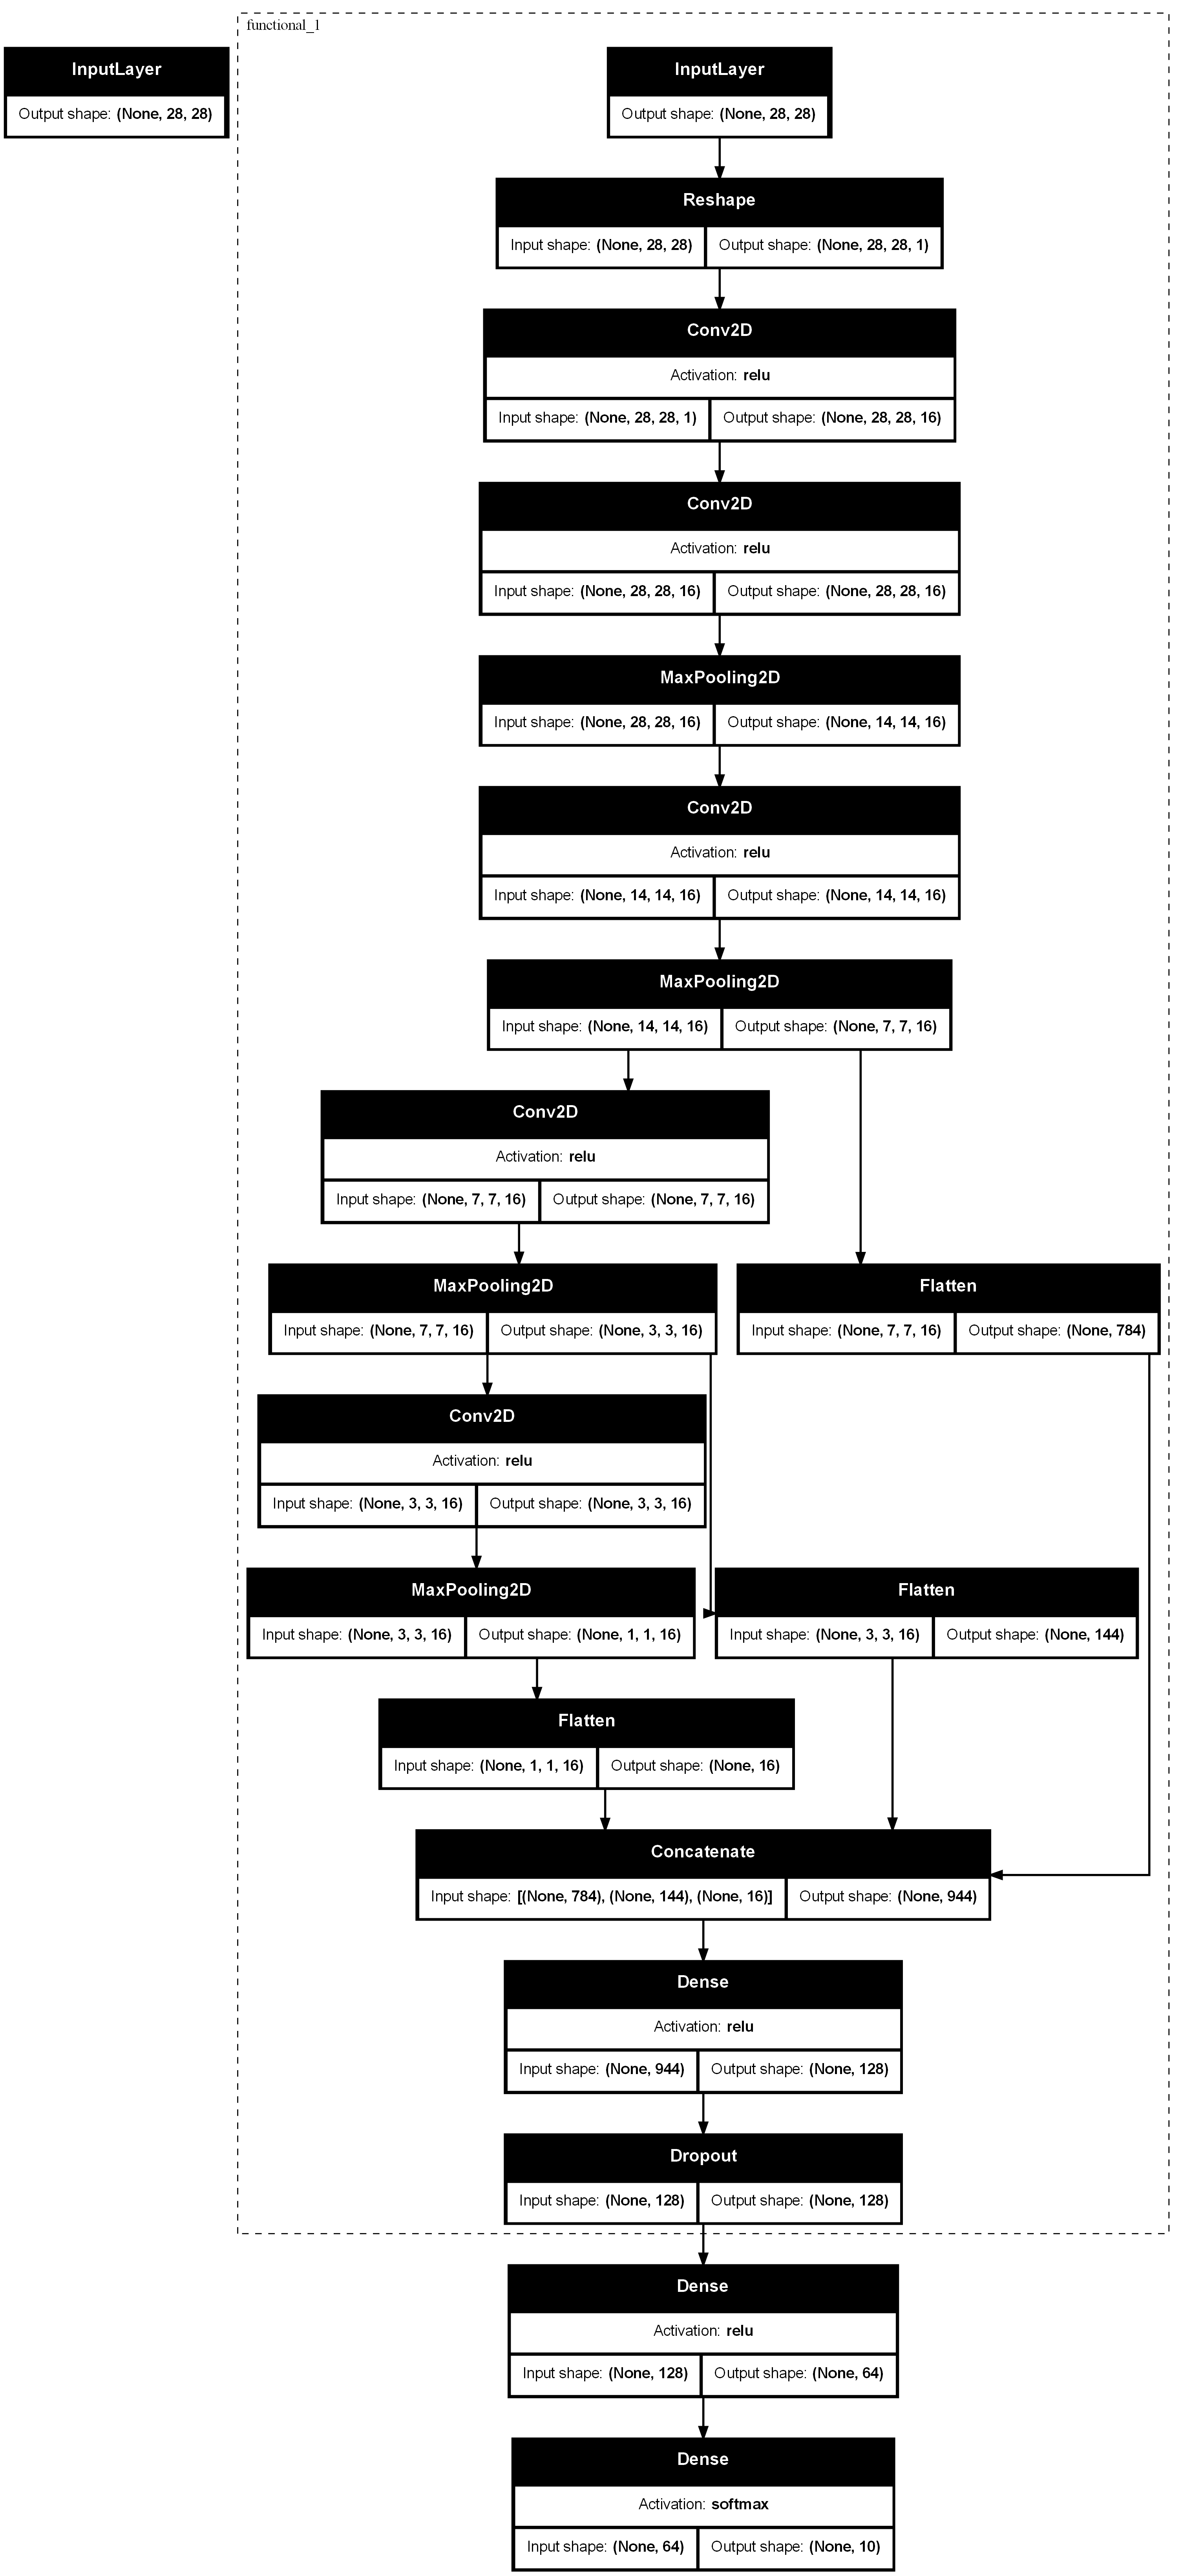

In [16]:
model2 = mymodel_2(sub_model=sub_model)

tf.keras.utils.plot_model(
    model = model2,
    show_layer_activations=True,
    show_shapes=True,
    expand_nested=True
)

In [17]:
model2.summary() 
### noter le nombre de paramètres "Non-Trainable": 
### ceux-ci correspondent au parametres déjà entrainé du (sub_)model

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ functional_1 (Functional)            │ (None, 128)                 │         136,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 145,578 (568.66 KB)

 Trainable params: 8,906 (34.79 KB)

 Non-trainable params: 136,672 (533.88 KB)

In [18]:
model2.fit(X_train_noise, y_train, validation_split=.2, epochs=5, batch_size=256)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.6229 - loss: 1.3372 - val_accuracy: 0.9703 - val_loss: 0.0964
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.9491 - loss: 0.1707 - val_accuracy: 0.9738 - val_loss: 0.0876
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.9559 - loss: 0.1437 - val_accuracy: 0.9738 - val_loss: 0.0850
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9616 - loss: 0.1291 - val_accuracy: 0.9752 - val_loss: 0.0832
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9628 - loss: 0.1257 - val_accuracy: 0.9760 - val_loss: 0.0817


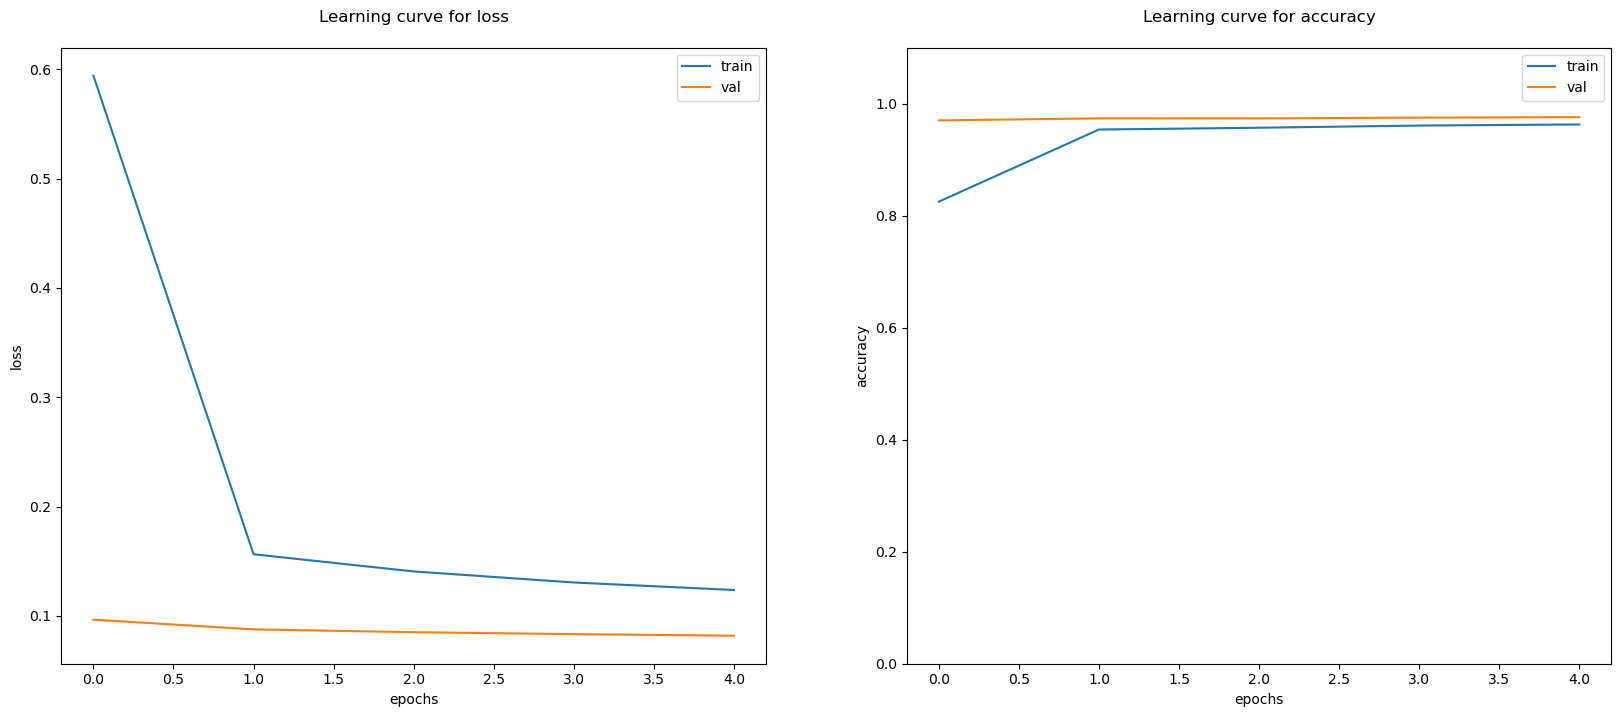

In [19]:
plot_lc(history=model2.history.history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


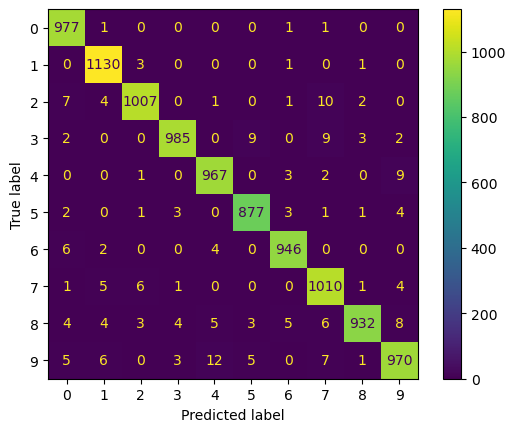

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.97      0.98      0.97      1028
           8       0.99      0.96      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [20]:
y_pred = np.argmax(model2.predict(X_test), axis=1)

plot_cm_display(y_test, y_pred)
print(classification_report(y_test, y_pred))